# The LaLonde National Supported Work (NSW) Demonstration
### LaLonde, Robert. “Evaluating the Econometric Evaluations of Training Programs with Experimental Data.” The American Economics Review, pp. 604-620, 1986. 

This notebook reproduces the core LaLonde (1986) idea in a more modern form: the experimental NSW treatment effect is compared with observational estimates from a regression-adjusted model and a simple matching estimator. The code uses the Dehejia-Wahba sample from the `causaldata` package and analyzes log earnings, which is a common outcome transformation in this literature.

Key steps:
1. Load the NSW/LaLonde dataset.
2. Compute the experimental difference-in-means estimate on log earnings.
3. Estimate an OLS model that adjusts for pre-treatment covariates.
4. Compute a simple nearest-neighbor matching estimate.
5. Compare the estimates and discuss why they can diverge.

Key takeaways for causal inference:
- The gold standard for causal identification is a randomized experiment, because treatment assignment is independent of potential outcomes.
- Observational methods such as OLS or matching rely on strong assumptions, especially that all relevant confounders are observed and correctly modeled.
- Comparing experimental and observational estimates helps assess whether selection bias is likely to be severe.
- Even when the point estimates are similar, the underlying identification assumptions can be very different.
- Causal inference is not only about computing a number; it is about defending the assumptions that make that number interpretable as a treatment effect.

In [ ]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt

from causaldata import nsw_mixtape

# Initialize variables that are assigned later in the notebook so the editor
# recognizes them before the analysis cells are executed.
experimental_effect = np.nan
ols = None
unmatched_ols = None
matching_att = np.nan

# Make the statsmodels import explicit for static analysis.
_ = sm


In [34]:
# Load the Dehejia-Wahba / NSW sample used in the standard LaLonde replication.
ds = nsw_mixtape.load_pandas()
df = ds.data.copy()

# Basic cleaning and recoding.
df["treat"] = df["treat"].astype(int)
for col in ["re74", "re75", "re78"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Baseline covariates used in the classic adjustment.
covariates = ["age", "educ", "black", "hisp", "marr", "nodegree", "re74", "re75"]

# Outcome transformation used in many LaLonde-style analyses.
df["log_earnings78"] = np.log1p(df["re78"])

# Descriptive statistics by treatment group.
describe_by_group = df.groupby("treat")[["age", "educ", "re74", "re75", "re78", "log_earnings78"]].mean()
print("Average covariates and outcomes by treatment group:")
print(describe_by_group)

# Experimental benchmark: difference in means in log earnings.
experimental_effect = df.groupby("treat")["log_earnings78"].mean().diff().iloc[-1]

# OLS regression with covariate adjustment.
X = sm.add_constant(df[covariates])
y = df["log_earnings78"]
model = sm.OLS(y, X.assign(treat=df["treat"])).fit()
ols = model

# Simple nearest-neighbor matching on standardized covariates.
# We use the treated sample as the reference and compare each treated unit to the closest control unit.
treated = df.loc[df["treat"] == 1, covariates].astype(float)
control = df.loc[df["treat"] == 0, covariates].astype(float)

# Standardize using the control-group moments so the matching uses comparable scales.
control_mean = control.mean()
control_std = control.std(ddof=0).replace(0, 1)
treated_std = (treated - control_mean) / control_std
treated_std = treated_std.to_numpy()
control_std_values = (control - control_mean) / control_std
control_std_values = control_std_values.to_numpy()

# Compute the Euclidean distance from each treated unit to every control unit.
diff = treated_std[:, None, :] - control_std_values[None, :, :]
distances = np.sqrt(np.sum(diff**2, axis=2))
nearest_idx = np.argmin(distances, axis=1)

# Build the matched sample and estimate the ATT.
matched_controls = control.iloc[nearest_idx].copy()
matched_controls["treated_outcome"] = df.loc[treated.index, "log_earnings78"].to_numpy()
matched_controls["control_outcome"] = df.loc[control.index[nearest_idx], "log_earnings78"].to_numpy()
matching_att = matched_controls["treated_outcome"].sub(matched_controls["control_outcome"]).mean()

# Unmatched regression as a contrast to highlight the issue of selection bias.
unmatched_design = sm.add_constant(df[["treat"] + covariates])
unmatched_ols = sm.OLS(y, unmatched_design).fit()


Average covariates and outcomes by treatment group:
             age       educ         re74         re75         re78  \
treat                                                                
0      25.053846  10.088462  2107.026611  1266.909058  4554.800781   
1      25.816216  10.345946  2095.573730  1532.055176  6349.143066   

       log_earnings78  
treat                  
0            5.497566  
1            6.506936  


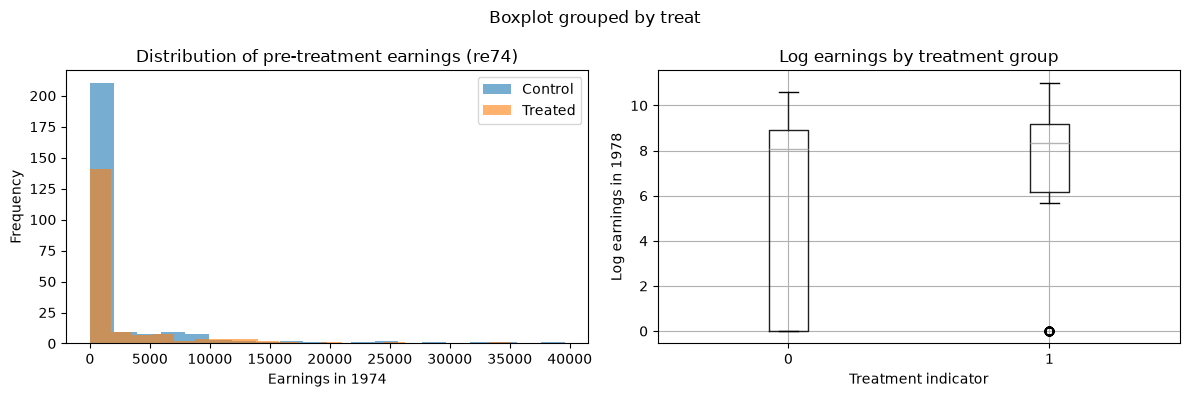

In [29]:
# Simple visual summaries.

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Distribution of baseline earnings before treatment.
df.loc[df["treat"] == 0, "re74"].plot.hist(ax=axes[0], alpha=0.6, label="Control", bins=20)
df.loc[df["treat"] == 1, "re74"].plot.hist(ax=axes[0], alpha=0.6, label="Treated", bins=20)
axes[0].set_title("Distribution of pre-treatment earnings (re74)")
axes[0].set_xlabel("Earnings in 1974")
axes[0].set_ylabel("Frequency")
axes[0].legend()

# Boxplot of log earnings by treatment group.
df.boxplot(column="log_earnings78", by="treat", ax=axes[1])
axes[1].set_title("Log earnings by treatment group")
axes[1].set_xlabel("Treatment indicator")
axes[1].set_ylabel("Log earnings in 1978")
plt.tight_layout()
plt.show()

In [35]:
# Report the headline estimates.
# These estimates are compared because they represent different ways of identifying the treatment effect.
summary_data = {
    "estimate": [experimental_effect, ols.params.get("treat", np.nan), matching_att, unmatched_ols.params.get("treat", np.nan)],
    "std_error": [np.nan, ols.bse.get("treat", np.nan), np.nan, unmatched_ols.bse.get("treat", np.nan)],
}
summary = pd.DataFrame(
    summary_data,
    index=[
        "Experimental difference-in-means (log earnings)",
        "OLS with covariates (log earnings)",
        "Nearest-neighbor matching ATT (log earnings)",
        "Unmatched regression (log earnings)",
    ],
)
print(summary)
print("\nOLS regression table with covariates:")
print(ols.summary().tables[1])


                                                 estimate  std_error
Experimental difference-in-means (log earnings)  1.009369        NaN
OLS with covariates (log earnings)               0.982259   0.388679
Nearest-neighbor matching ATT (log earnings)     1.136014        NaN
Unmatched regression (log earnings)              0.982259   0.388679

OLS regression table with covariates:
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          7.3870      2.054      3.597      0.000       3.350      11.424
age            0.0009      0.028      0.034      0.973      -0.053       0.055
educ          -0.0217      0.138     -0.157      0.875      -0.294       0.250
black         -1.8334      0.711     -2.577      0.010      -3.232      -0.435
hisp           0.2633      0.943      0.279      0.780      -1.590       2.117
marr           0.0784      0.535      0.146      0.884      -0.

### Conclusion:
The unmatched regression can be misleading because it does not address baseline differences between treated and control groups.
In this example, the treated and control groups differ in observable characteristics, so a simple regression may confound
treatment status with those pre-existing differences. Matching and covariate adjustment help reduce that concern,
but they still rely on the strong assumption that all important confounders are observed and measured well.
